# Practice 15 — Advanced CNN

기본 2-layer CNN을 넘어, 모던 CNN의 핵심 기법을 **한꺼번에 적용한 최종 모델**의 학습 결과를 compact 하게 봅니다. 그 뒤 **ImageNet 사전학습 ResNet18** 을 **동일한 데이터 조건**에서 fine-tuning 해 한 단계 더 큰 도약을 확인합니다.

| 모델 | 구성 |
|------|------|
| **Custom Final CNN** | Conv 4-layer + Kaiming 초기화 + BatchNorm2d + Dropout(0.5) + Aug(RandomCrop96 + HFlip), 15 epoch |
| **Pretrained ResNet18** | ImageNet 120만장 사전학습 backbone. **앞부분(conv1+layer1~2) 동결, 뒤(layer3~4+FC) 만 fine-tuning**, 5 epoch |

**두 모델 공통 조건 (격리된 차이는 모델·optimizer·epoch 뿐):**

| 항목 | 값 |
|------|----|
| 데이터 | CIFAR-10 10000장(train) / 2000장(val) subset (속도 절충) |
| Input size | 96 x 96 (Resize) |
| 정규화 통계 | ImageNet 표준 (mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)) |
| Augmentation | RandomCrop(96, padding=8) + RandomHorizontalFlip(p=0.5) — train 만 |
| Batch size | 64 |

> Custom CNN 도 ImageNet 정규화를 사용하는 이유: **두 모델이 정확히 같은 입력 분포를 받게** 해서 결과 차이를 모델 자체로 귀속시키기 위함. CIFAR 통계를 따로 쓰면 정규화 차이까지 변수가 되어 비교가 불순해짐.


In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('device:', device)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
device: cuda


---
# 1. CIFAR-10 데이터 파이프라인 (두 모델 공용)

Custom Dataset 템플릿으로 CIFAR-10 의 **train 10000장 / val 2000장** 부분집합을 가져옵니다. 두 모델 모두 이 동일한 `train_loader`, `val_loader` 를 사용합니다. (전체 50000장을 쓰면 모델 차이는 더 잘 보이지만 학습 시간이 매우 길어지므로 부분집합 사용.)

> torchvision 은 train/test 만 제공 — 여기선 그 test set 을 val 로 사용해 학습 모니터링. 실무에선 train 일부를 별도 val 로 떼고 진짜 test 는 마지막에 1회만 사용.


In [2]:
# CIFAR-10 데이터를 감싸는 사용자 정의 Dataset (PyTorch 표준 구조 — 템플릿)
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X                        # numpy uint8 (N, 32, 32, 3)
        self.y = y                        # numpy int    (N,)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx])
        if self.transform is not None:
            img = self.transform(img)
        return img, self.y[idx]

In [3]:
# ImageNet 표준 정규화 통계 — 두 모델 공통으로 사용
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Train transform: Resize 96 + RandomCrop + HFlip + Normalize
transform_train = transforms.Compose([
    transforms.Resize(96),
    transforms.RandomCrop(96, padding=8),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Val transform: Resize 96 + Normalize (augmentation 없음)
transform_val = transforms.Compose([
    transforms.Resize(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# CIFAR-10 다운로드 (numpy 형태로 직접 다루기 위해 transform 없이 로드)
cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar_val   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

X_train = cifar_train.data[:10000]
y_train = np.array(cifar_train.targets[:10000])
X_val   = cifar_val.data[:2000]
y_val   = np.array(cifar_val.targets[:2000])

train_set = CIFAR10Dataset(X_train, y_train, transform=transform_train)
val_set   = CIFAR10Dataset(X_val,   y_val,   transform=transform_val)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=0)

class_names = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Train: {len(train_set)} samples (Resize 96 + RandomCrop + HFlip + ImageNet normalize)')
print(f'Val  : {len(val_set)} samples (Resize 96 + ImageNet normalize)')

Train: 10000 samples (Resize 96 + RandomCrop + HFlip + ImageNet normalize)
Val  : 2000 samples (Resize 96 + ImageNet normalize)


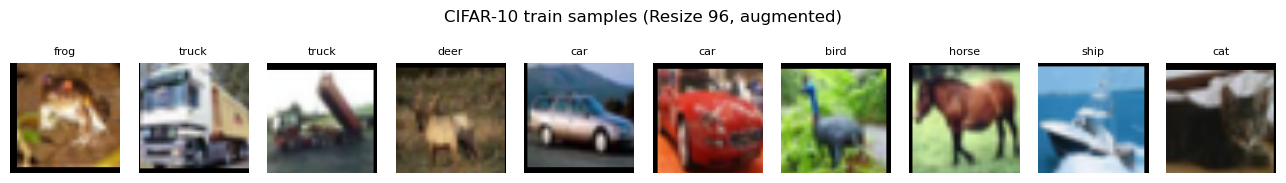

In [4]:
# 정규화된 텐서를 다시 표시 가능한 이미지로 되돌리는 헬퍼
mean_arr = np.array(IMAGENET_MEAN)
std_arr  = np.array(IMAGENET_STD)

def unnormalize(img_t):
    img = img_t.permute(1, 2, 0).numpy() * std_arr + mean_arr
    return np.clip(img, 0, 1)

# 샘플 10장 시각화 (train_set 은 augmentation 적용된 결과)
fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    img_i, label_i = train_set[i]
    axes[i].imshow(unnormalize(img_i))
    axes[i].set_title(class_names[label_i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 train samples (Resize 96, augmented)', y=1.05)
plt.tight_layout(); plt.show()

---
# 2. 학습 함수 정의

표준 `train` / `evaluate` 함수. 학습 중 모니터링은 **val_loader** 로만 수행.


In [5]:
# 학습 - epochs 만큼 학습 + 매 epoch val 평가
# (train_losses, train_accs, val_losses, val_accs) 반환
def train(model, train_loader, val_loader, optimizer, epochs, device):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        loss_sum, correct, count = 0.0, 0, 0
        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
        train_loss = loss_sum / len(train_loader)
        train_acc = correct / count
        val_loss, val_acc, _ = evaluate(model, val_loader, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f'  Epoch {epoch+1:2d}/{epochs}  '
              f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
              f'train_acc={train_acc:.4f}  val_acc={val_acc:.4f}')
    return train_losses, train_accs, val_losses, val_accs


# 평가 - (loss, accuracy, y_pred) 반환
def evaluate(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, count = 0.0, 0, 0
    preds = []
    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            output = model(X_batch)
            loss_sum += criterion(output, Y_batch).item()
            correct += (output.argmax(1) == Y_batch).sum().item()
            count += len(Y_batch)
            preds.append(output.argmax(1).cpu())
    y_pred = torch.cat(preds).numpy()
    return loss_sum / len(loader), correct / count, y_pred

---
# 3. Custom Final CNN — Deep + BN + Dropout

**Conv-BN-ReLU 블록을 4개 쌓고**, FC 직전에 Dropout(0.5) 을 둔 4-layer 모델. 96x96 입력을 받아 점차 줄여 마지막 6x6 feature map → FC.

$$\hat{x}_{n,c,h,w} = \frac{x_{n,c,h,w} - \mu_c}{\sqrt{\sigma_c^2 + \epsilon}}, \qquad y_{n,c,h,w} = \gamma_c\,\hat{x}_{n,c,h,w} + \beta_c$$

**아키텍처 (입력 3 x 96 x 96):**
```
[Conv-BN-ReLU-Pool] x4 -> Flatten -> Dropout(0.5) -> Linear(128*6*6, 10)
```


In [6]:
# Conv 4-layer + BN + Dropout + Kaiming(He) 초기화 (입력 96x96)
class CNN_Final(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 96 -> 48
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 48 -> 24
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 24 -> 12
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2))                  # 12 -> 6
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(128 * 6 * 6, 10)
        # Kaiming(He) 초기화 - ReLU와 짝
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print(f'Custom Final CNN params: {sum(p.numel() for p in CNN_Final().parameters()):,}')

Custom Final CNN params: 287,626


In [7]:
torch.manual_seed(42)
model_custom = CNN_Final().to(device)
optimizer_custom = torch.optim.SGD(model_custom.parameters(), lr=0.01, momentum=0.9)
print(f'Training Custom Final CNN on {device}...')
train_losses_custom, train_accs_custom, val_losses_custom, val_accs_custom = train(
    model_custom, train_loader, val_loader, optimizer_custom, epochs=30, device=device)
print()
print(f'Custom Final final val acc: {val_accs_custom[-1]:.4f}  (peak: {max(val_accs_custom):.4f})')

Training Custom Final CNN on cuda...


  Epoch  1/30  train_loss=2.7433  val_loss=1.6929  train_acc=0.2949  val_acc=0.4035


  Epoch  2/30  train_loss=1.6681  val_loss=1.4937  train_acc=0.4031  val_acc=0.4565


  Epoch  3/30  train_loss=1.5150  val_loss=1.3779  train_acc=0.4447  val_acc=0.4960


  Epoch  4/30  train_loss=1.4288  val_loss=1.3452  train_acc=0.4819  val_acc=0.5060


...

  Epoch 26/30  train_loss=0.7662  val_loss=0.8108  train_acc=0.7303  val_acc=0.7215


  Epoch 27/30  train_loss=0.7533  val_loss=0.7894  train_acc=0.7401  val_acc=0.7235


  Epoch 28/30  train_loss=0.7381  val_loss=0.8325  train_acc=0.7407  val_acc=0.7210


  Epoch 29/30  train_loss=0.7421  val_loss=0.7911  train_acc=0.7385  val_acc=0.7405


  Epoch 30/30  train_loss=0.7150  val_loss=0.7855  train_acc=0.7471  val_acc=0.7420

Custom Final final val acc: 0.7420  (peak: 0.7420)


---
# 4. Pretrained ResNet18 — Partial Fine-tuning (앞쪽 레이어 동결)

**같은 `train_loader`, `val_loader`** 위에서 ImageNet 사전학습 ResNet18 을 가져와 다음 두 단계로 처리:

1. **앞쪽 레이어 동결** (`conv1`, `bn1`, `layer1`, `layer2`) — `requires_grad=False` 로 설정해 학습 시 가중치 갱신 안 함
2. **뒤쪽 레이어만 fine-tuning** (`layer3`, `layer4`, 새 `fc`) — 새로 만든 `fc` 는 기본적으로 `requires_grad=True`

**왜 앞쪽을 동결?**
- 사전학습 ResNet18 의 앞쪽 conv 들은 ImageNet 120만장에서 학습된 **일반적 시각 특징** (엣지·코너·텍스처·색 패턴) 을 추출. 이는 어떤 자연 이미지에도 거의 그대로 유효해 굳이 다시 학습할 필요 없음.
- 뒤쪽 레이어는 **task-specific** (ImageNet 1000클래스 식별용 고수준 특징) 이므로 CIFAR-10 10클래스에 맞게 재학습.
- 결과: 학습 속도가 빨라지고, 작은 데이터셋에서 과적합 위험도 줄어듬.

| 항목 | 값 (Custom 과의 차이) |
|------|----------------------|
| 모델 | Pretrained ResNet18 (conv1+layer1~2 동결, layer3~4+FC 학습) ← **다름** |
| Optimizer | SGD(lr=0.001, momentum=0.9), trainable 파라미터만 ← **다름** |
| Epoch | 5 ← **다름** (사전학습 + 동결로 짧게도 충분) |
| 데이터·정규화·input size·aug·batch | 위 train/val loader 그대로 ← **동일** |

> **CUDA 권장.** CPU 에서는 매우 느림.


In [8]:
from torchvision.models import resnet18, ResNet18_Weights

torch.manual_seed(42)
resnet_full = resnet18(weights=ResNet18_Weights.DEFAULT)

# (1) 전체 파라미터 동결
for param in resnet_full.parameters():
    param.requires_grad = False

# (2) 뒤쪽 layer3, layer4 동결 해제 (다시 학습 가능하게)
for param in resnet_full.layer4.parameters():
    param.requires_grad = True

# (3) 마지막 FC 를 10-class 로 교체 (새 Linear 는 기본적으로 requires_grad=True)
resnet_full.fc = nn.Linear(resnet_full.fc.in_features, 10)

resnet_full = resnet_full.to(device)

# 파라미터 통계
n_total = sum(p.numel() for p in resnet_full.parameters())
n_train = sum(p.numel() for p in resnet_full.parameters() if p.requires_grad)
print(f'Total     params: {n_total:,}')
print(f'Trainable params: {n_train:,}  ({n_train/n_total:.1%})')
print()

# 학습 전 - FC가 random 초기값이므로 chance level(~10%) 예상
_, acc_before, _ = evaluate(resnet_full, val_loader, device)
print()
print(f'[Before fine-tuning] val accuracy = {acc_before:.4f}  (random FC, ~10% 예상)')

Total     params: 11,181,642
Trainable params: 8,398,858  (75.1%)




[Before fine-tuning] val accuracy = 0.0815  (random FC, ~10% 예상)


In [9]:
# optimizer 는 trainable 파라미터만 모아서 전달 (동결된 건 update 안 함)
trainable_params = [p for p in resnet_full.parameters() if p.requires_grad]
optimizer_resnet = torch.optim.SGD(trainable_params, lr=0.001, momentum=0.9)

import time
print(f'Partial fine-tuning ResNet18 on CIFAR-10 (10k subset, 96x96) on {device}...')
t0 = time.time()
train_losses_resnet, train_accs_resnet, val_losses_resnet, val_accs_resnet = train(
    resnet_full, train_loader, val_loader, optimizer_resnet, epochs=10, device=device)
elapsed = time.time() - t0
print()
print(f'Elapsed: {elapsed:.1f}s on {device}')
print(f'ResNet18 final val acc: {val_accs_resnet[-1]:.4f}  (peak: {max(val_accs_resnet):.4f})')

Partial fine-tuning ResNet18 on CIFAR-10 (10k subset, 96x96) on cuda...


  Epoch  1/10  train_loss=1.3578  val_loss=0.8784  train_acc=0.5346  val_acc=0.6885


  Epoch  2/10  train_loss=0.7702  val_loss=0.7038  train_acc=0.7381  val_acc=0.7555


  Epoch  3/10  train_loss=0.6295  val_loss=0.6342  train_acc=0.7813  val_acc=0.7745


  Epoch  4/10  train_loss=0.5643  val_loss=0.5868  train_acc=0.8081  val_acc=0.7970


...

  Epoch  6/10  train_loss=0.4398  val_loss=0.5263  train_acc=0.8504  val_acc=0.8140


  Epoch  7/10  train_loss=0.4250  val_loss=0.5207  train_acc=0.8542  val_acc=0.8185


  Epoch  8/10  train_loss=0.3896  val_loss=0.4995  train_acc=0.8672  val_acc=0.8245


  Epoch  9/10  train_loss=0.3465  val_loss=0.4909  train_acc=0.8827  val_acc=0.8315


  Epoch 10/10  train_loss=0.3304  val_loss=0.4622  train_acc=0.8872  val_acc=0.8365

Elapsed: 39.6s on cuda
ResNet18 final val acc: 0.8365  (peak: 0.8365)


---
# 5. 비교 — Custom Final vs Pretrained ResNet18

**두 모델은 정확히 같은 데이터 / 같은 정규화 / 같은 augmentation / 같은 input size / 같은 batch size 위에서 학습.** 차이는 모델 구조와 (의도된) optimizer · epoch 수 뿐. 따라서 정확도 차이는 **모델 자체의 표현력 + 사전학습 효과**로 귀속할 수 있음.

epoch 수가 다르므로 (Custom 15 vs ResNet18 5) **각자 마지막 epoch 의 val 성능**을 함께 봅니다.


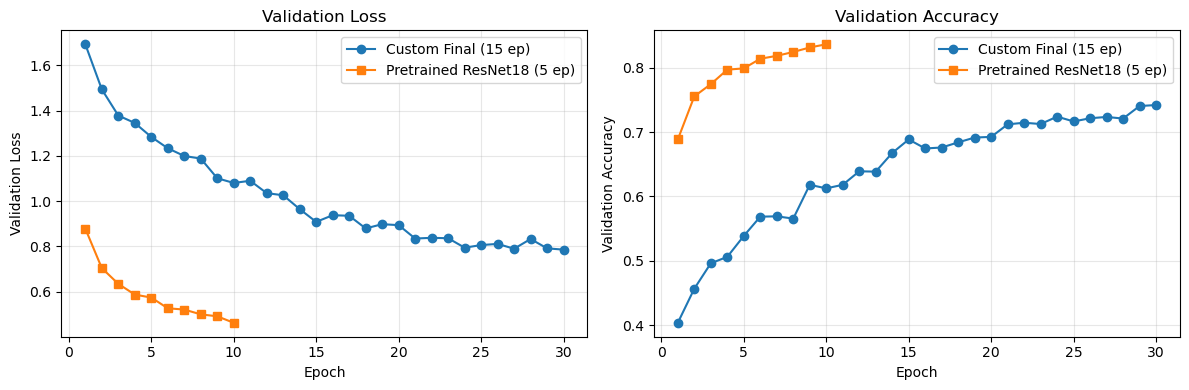

Custom Final       peak val acc: 0.7420
Pretrained ResNet18 peak val acc: 0.8365


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(val_losses_custom)+1), val_losses_custom, 'o-', label='Custom Final (15 ep)')
axes[0].plot(range(1, len(val_losses_resnet)+1), val_losses_resnet, 's-', label='Pretrained ResNet18 (5 ep)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(val_accs_custom)+1), val_accs_custom, 'o-', label='Custom Final (15 ep)')
axes[1].plot(range(1, len(val_accs_resnet)+1), val_accs_resnet, 's-', label='Pretrained ResNet18 (5 ep)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f'Custom Final       peak val acc: {max(val_accs_custom):.4f}')
print(f'Pretrained ResNet18 peak val acc: {max(val_accs_resnet):.4f}')

---
# 6. 훈련 결과 시각화 (Pretrained ResNet18)

승자인 ResNet18 모델로 val set 전체 예측을 한 번 더 수집해 두 가지로 살펴봅니다. (torchvision 표준 벤치마크라 별도 test set 은 없음 — 마지막 epoch 의 val 성능이 그 위치의 최종 지표.)

- **틀린 예측 4 개**: 1 × 4 그리드, 제목 `True:X / Pred:Y` (빨강)
- **Confusion Matrix**: 어떤 클래스가 어떤 클래스로 오인되는지


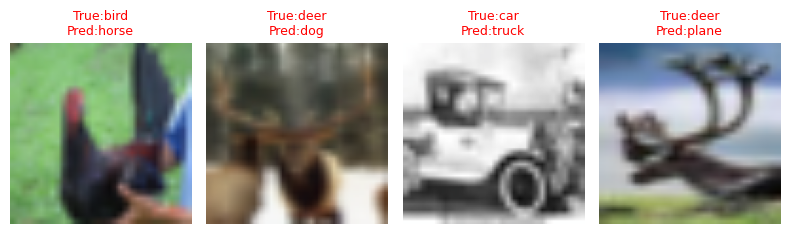

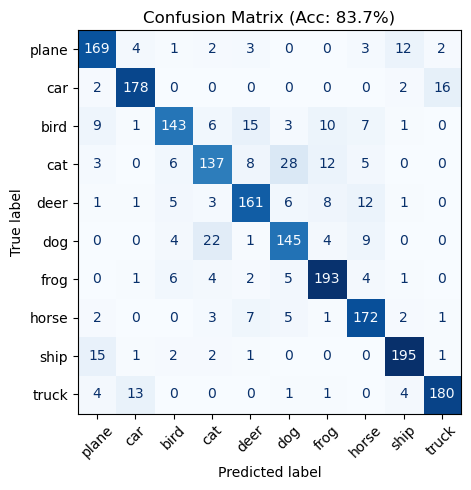

In [11]:
# ResNet18 예측 수집
_, resnet_val_acc, y_pred = evaluate(resnet_full, val_loader, device)

# (1) 틀린 예측 4 개 - 1 x 4 subplot
wrong_idx = np.where(y_pred != y_val)[0]
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for i in range(min(4, len(wrong_idx))):
    idx = wrong_idx[i]
    img_tensor, _ = val_set[idx]
    axes[i].imshow(unnormalize(img_tensor))
    axes[i].set_title(f'True:{class_names[y_val[idx]]}\nPred:{class_names[y_pred[idx]]}',
                      color='red', fontsize=9)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

# (2) Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Confusion Matrix (Acc: {resnet_val_acc:.1%})')
plt.tight_layout(); plt.show()

---
# 7. 정리

**비교 조건 (격리된 차이는 모델·optimizer·epoch 뿐):**

| 항목 | Custom Final | Pretrained ResNet18 |
|------|--------------|--------------------|
| 데이터 | 10k train / 2k val subset | **동일** |
| Input | Resize 96 + ImageNet normalize | **동일** |
| Augmentation | RandomCrop96 + HFlip | **동일** |
| Batch size | 64 | **동일** |
| 모델 | Conv4 + BN + Dropout(0.5), from scratch | ImageNet pretrained ResNet18: conv1+layer1~2 동결, layer3~4+새 FC fine-tuning |
| Optimizer | SGD(lr=0.01, momentum=0.9) | SGD(lr=0.001, momentum=0.9), trainable 만 |
| Epoch | 15 | 5 |

> **핵심 메시지**: 데이터·전처리·aug 가 모두 동일한 조건에서 비교했을 때, **ImageNet 사전학습 backbone 의 fine-tuning** 이 from-scratch 4-layer CNN 보다 더 짧은 학습으로 더 높은 정확도를 달성. 사전학습이 학습 데이터로부터 얻기 어려운 일반적 시각 표현을 이미 갖고 있기 때문.

---
### 연습 문제

1. Custom Final 모델의 `Dropout(0.5)` 을 `Dropout(0.3)` 으로 낮추거나, augmentation 을 빼면 val 정확도가 어떻게 달라지나요?
2. `ResNet18` 을 `resnet34`, `mobilenet_v2` 등으로 바꿔 정확도/시간을 비교해 보세요.
3. 자신의 사진을 `data/my_photos/<클래스명>/<파일.jpg>` 형태로 저장하고 ImageFolder 패턴 + Section 4 의 ResNet18 fine-tuning 코드를 그대로 응용해 학습해 보세요.


In [12]:
# 연습 문제 풀이 공간